In [8]:
# Cell 1: Import Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
import tarfile
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!



Attempting to load California housing dataset...
Local file not found. Attempting standard download...
Error during loading: HTTP Error 403: Forbidden

Loading from fallback CSV URL...
Raw CSV data loaded. Processing columns...
Missing values handled. Remaining NaN count: 0

Dataset processed successfully! Using 10 columns.
Note: Using fallback CSV data with derived features.

DATASET SUCCESSFULLY LOADED

Dataset Shape: (20640, 10)
Rows: 20640, Columns: 10

Column Names and Data Types:
----------------------------------------
MedInc               : float64    (20640 non-null values)
HouseAge             : float64    (20640 non-null values)
AveRooms             : float64    (20640 non-null values)
AveBedrms            : float64    (20640 non-null values)
Population           : float64    (20640 non-null values)
AveOccup             : float64    (20640 non-null values)
Latitude             : float64    (20640 non-null values)
Longitude            : float64    (20640 non-null values)
Med

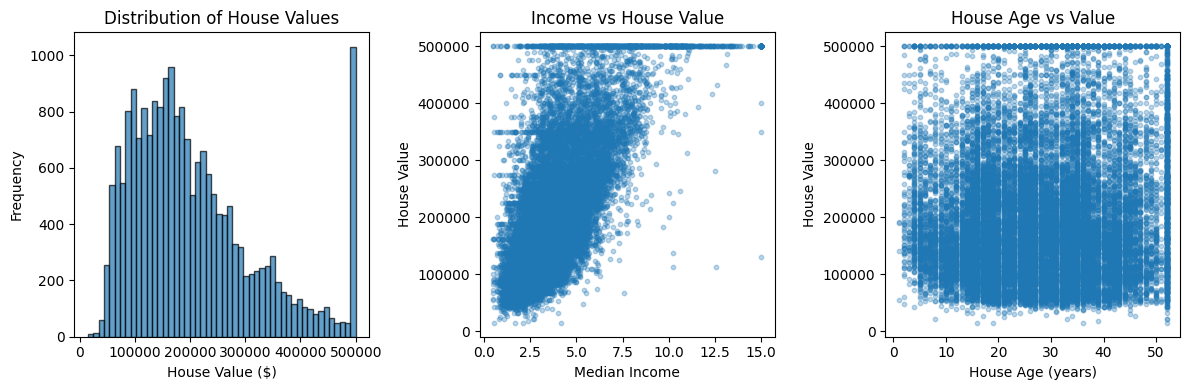


Dataset is ready for analysis!


In [9]:
# Cell 2: Load and Explore Dataset (Corrected Version)
import tarfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\nAttempting to load California housing dataset...")

# Define the local path for the manually downloaded file
local_tgz_path = '/kaggle/working/cal_housing.tgz'

try:
    if os.path.exists(local_tgz_path):
        print(f"Found local file at: {local_tgz_path}")
        with tarfile.open(local_tgz_path, 'r:gz') as tar:
            tar.extractall(path='/kaggle/working/')
        print("File extracted successfully.")
        housing = fetch_california_housing(data_home='/kaggle/working/', download_if_missing=False)
        print("Dataset loaded from local file!")
        # Convert to DataFrame
        df = pd.DataFrame(housing.data, columns=housing.feature_names)
        df['MedHouseVal'] = housing.target
    else:
        print("Local file not found. Attempting standard download...")
        housing = fetch_california_housing(download_if_missing=True, n_retries=3, delay=2.0)
        print("Dataset loaded from source.")
        # Convert to DataFrame
        df = pd.DataFrame(housing.data, columns=housing.feature_names)
        df['MedHouseVal'] = housing.target
        
except Exception as e:
    print(f"Error during loading: {e}")
    print("\nLoading from fallback CSV URL...")
    
    # Fallback to CSV with proper data handling
    csv_url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
    df = pd.read_csv(csv_url)
    
    print("Raw CSV data loaded. Processing columns...")
    
    # Convert object columns to numeric (handle errors by setting to NaN)
    numeric_columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 
                      'total_bedrooms', 'population', 'households', 'median_income']
    
    for col in numeric_columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Fill missing values in numeric columns with median
    df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())
    
    # Convert target column (already exists as 'median_house_value')
    df['median_house_value'] = pd.to_numeric(df['median_house_value'], errors='coerce')
    
    print(f"Missing values handled. Remaining NaN count: {df.isna().sum().sum()}")
    
    # For consistency with original dataset, rename and prepare features
    # Create derived features similar to original dataset
    if 'total_rooms' in df.columns and 'households' in df.columns:
        df['AveRooms'] = df['total_rooms'] / df['households']
        df['AveBedrms'] = df['total_bedrooms'] / df['households']
        df['AveOccup'] = df['population'] / df['households']
    
    # Select and rename columns to match original dataset structure
    column_mapping = {
        'median_income': 'MedInc',
        'housing_median_age': 'HouseAge',
        'population': 'Population',
        'households': 'Households',
        'latitude': 'Latitude',
        'longitude': 'Longitude',
        'median_house_value': 'MedHouseVal'
    }
    
    # Apply renaming for columns that exist
    for old_name, new_name in column_mapping.items():
        if old_name in df.columns:
            df[new_name] = df[old_name]
    
    # CORRECTED: Keep only the columns we need for analysis (INCLUDING Households)
    keep_columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
                   'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'Households']
    
    # Filter to only keep columns that exist
    existing_columns = [col for col in keep_columns if col in df.columns]
    df = df[existing_columns]
    
    print(f"\nDataset processed successfully! Using {len(existing_columns)} columns.")
    print("Note: Using fallback CSV data with derived features.")

print("\n" + "="*60)
print("DATASET SUCCESSFULLY LOADED")
print("="*60)

print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nColumn Names and Data Types:")
print("-" * 40)
for col in df.columns:
    dtype = str(df[col].dtype)
    non_null = df[col].count()
    print(f"{col:20} : {dtype:10} ({non_null} non-null values)")

print("\nFirst 5 rows of data:")
print("-" * 40)
print(df.head())

print("\nBasic Statistics:")
print("-" * 40)
print(df.describe())

print("\nMissing Values Check:")
print("-" * 40)
print(df.isnull().sum())

# Display a sample of the data
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of House Values')
plt.xlabel('House Value ($)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
if 'MedInc' in df.columns:
    plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3, s=10)
    plt.title('Income vs House Value')
    plt.xlabel('Median Income')
    plt.ylabel('House Value')

plt.subplot(1, 3, 3)
if 'HouseAge' in df.columns:
    plt.scatter(df['HouseAge'], df['MedHouseVal'], alpha=0.3, s=10)
    plt.title('House Age vs Value')
    plt.xlabel('House Age (years)')
    plt.ylabel('House Value')

plt.tight_layout()
plt.show()

print("\nDataset is ready for analysis!")

In [10]:
# Cell 3: Feature Engineering and Data Preprocessing
print("="*60)
print("FEATURE ENGINEERING AND DATA PREPROCESSING")
print("="*60)

# Check current features
print("Current features:", list(df.columns))
print("\n")

# Create new derived features for better predictive power
# Note: Some features like AveRooms, AveBedrms, AveOccup already exist from fallback data
# We'll create additional meaningful features

# 1. Create interaction features
df['IncomePerRoom'] = df['MedInc'] / (df['AveRooms'] + 1e-10)  # Add small constant to avoid division by zero
df['LatLongInteraction'] = df['Latitude'] * df['Longitude']

# 2. Create polynomial features for MedInc (square and cube)
df['MedInc_Squared'] = df['MedInc'] ** 2
df['MedInc_Cubed'] = df['MedInc'] ** 3

# 3. Create age groups (binned feature)
df['AgeGroup'] = pd.cut(df['HouseAge'], 
                        bins=[0, 10, 30, 52], 
                        labels=['New', 'Medium', 'Old'])

# 4. Create population density feature
df['PopulationDensity'] = df['Population'] / (df['Households'] + 1e-10)

print("New features created:")
print("-" * 40)
print(f"Total features: {len(df.columns)}")
print("New features added: IncomePerRoom, LatLongInteraction, MedInc_Squared, MedInc_Cubed, AgeGroup, PopulationDensity")

# Handle categorical variable (AgeGroup) - One-Hot Encoding
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)

print(f"\nAfter one-hot encoding, total features: {len(df.columns)}")

# Prepare features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"\nTraining set: {X_train.shape}, {y_train.shape}")
print(f"Testing set: {X_test.shape}, {y_test.shape}")

# Handle outliers using RobustScaler (less sensitive to outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nFeature scaling completed using RobustScaler")
print("First 3 rows of scaled training data:")
print(X_train_scaled.head(3))

print("\nData preprocessing completed successfully!")

FEATURE ENGINEERING AND DATA PREPROCESSING
Current features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'Households']


New features created:
----------------------------------------
Total features: 16
New features added: IncomePerRoom, LatLongInteraction, MedInc_Squared, MedInc_Cubed, AgeGroup, PopulationDensity

After one-hot encoding, total features: 17

Features shape: (20640, 16)
Target shape: (20640,)

Training set: (16512, 16), (16512,)
Testing set: (4128, 16), (4128,)

Feature scaling completed using RobustScaler
First 3 rows of scaled training data:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
14196 -0.129709  0.210526 -0.135624  -0.456789    1.209178  1.027459   
8267   0.120872  1.052632 -0.473796  -0.088238    0.156884 -1.267790   
17445  0.276686 -1.315789  0.254794  -0.683787   -0.268943 -0.110462   

       Latitude  Longitude  Households  IncomePerRoom  LatLongInteraction  

In [11]:
# Cell 4: Feature Selection
print("="*60)
print("FEATURE SELECTION")
print("="*60)

# Use SelectKBest with f_regression to select top features
k = 12  # Select top 12 features (adjust based on your needs)
selector = SelectKBest(score_func=f_regression, k=k)

# Fit selector to training data
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = X_train_scaled.columns[selector.get_support()]
print(f"Selected top {k} features:")
print("-" * 40)
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

print(f"\nOriginal features: {X_train_scaled.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

# Update scaled datasets with selected features
X_train_scaled = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

print("\nFeature selection completed successfully!")

FEATURE SELECTION
Selected top 12 features:
----------------------------------------
1. MedInc
2. HouseAge
3. AveRooms
4. AveBedrms
5. Latitude
6. Households
7. IncomePerRoom
8. LatLongInteraction
9. MedInc_Squared
10. MedInc_Cubed
11. AgeGroup_Medium
12. AgeGroup_Old

Original features: 16
Selected features: 12

Feature selection completed successfully!


In [12]:
# Cell 5: Model Training and Evaluation
print("="*60)
print("MODEL TRAINING AND EVALUATION")
print("="*60)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                                cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    
    # Train on full training set
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std(),
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'y_test_pred': y_test_pred
    }
    
    # Print results
    print(f"  Cross-validation RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
    print(f"  Training RMSE: {train_rmse:.2f}, R²: {train_r2:.4f}")
    print(f"  Testing RMSE: {test_rmse:.2f}, R²: {test_r2:.4f}")

print("\nModel training completed!")

MODEL TRAINING AND EVALUATION

Training Linear Regression...
  Cross-validation RMSE: 70023.35 ± 1039.96
  Training RMSE: 69906.38, R²: 0.6344
  Testing RMSE: 84801.67, R²: 0.4512

Training Ridge Regression...
  Cross-validation RMSE: 70071.63 ± 1027.11
  Training RMSE: 69930.52, R²: 0.6342
  Testing RMSE: 85128.84, R²: 0.4470

Training Lasso Regression...
  Cross-validation RMSE: 70026.21 ± 1037.69
  Training RMSE: 69906.59, R²: 0.6344
  Testing RMSE: 84868.79, R²: 0.4503

Training Random Forest...
  Cross-validation RMSE: 58668.04 ± 370.86
  Training RMSE: 21691.13, R²: 0.9648
  Testing RMSE: 58666.22, R²: 0.7374

Training Gradient Boosting...
  Cross-validation RMSE: 61900.28 ± 630.06
  Training RMSE: 59101.62, R²: 0.7387
  Testing RMSE: 62861.27, R²: 0.6984

Model training completed!


In [13]:
# Cell 6: Hyperparameter Tuning
print("="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Tune Random Forest
print("\nTuning Random Forest...")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train_scaled, y_train)

print(f"Best Random Forest parameters: {rf_grid.best_params_}")
print(f"Best Random Forest CV score: {np.sqrt(-rf_grid.best_score_):.2f}")

# Tune Gradient Boosting
print("\nTuning Gradient Boosting...")
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
gb_grid.fit(X_train_scaled, y_train)

print(f"Best Gradient Boosting parameters: {gb_grid.best_params_}")
print(f"Best Gradient Boosting CV score: {np.sqrt(-gb_grid.best_score_):.2f}")

# Update models with best parameters
results['Random Forest (Tuned)'] = {
    'model': rf_grid.best_estimator_,
    'train_rmse': np.sqrt(mean_squared_error(y_train, rf_grid.best_estimator_.predict(X_train_scaled))),
    'test_rmse': np.sqrt(mean_squared_error(y_test, rf_grid.best_estimator_.predict(X_test_scaled))),
    'train_r2': r2_score(y_train, rf_grid.best_estimator_.predict(X_train_scaled)),
    'test_r2': r2_score(y_test, rf_grid.best_estimator_.predict(X_test_scaled)),
    'y_test_pred': rf_grid.best_estimator_.predict(X_test_scaled)
}

results['Gradient Boosting (Tuned)'] = {
    'model': gb_grid.best_estimator_,
    'train_rmse': np.sqrt(mean_squared_error(y_train, gb_grid.best_estimator_.predict(X_train_scaled))),
    'test_rmse': np.sqrt(mean_squared_error(y_test, gb_grid.best_estimator_.predict(X_test_scaled))),
    'train_r2': r2_score(y_train, gb_grid.best_estimator_.predict(X_train_scaled)),
    'test_r2': r2_score(y_test, gb_grid.best_estimator_.predict(X_test_scaled)),
    'y_test_pred': gb_grid.best_estimator_.predict(X_test_scaled)
}

print("\nHyperparameter tuning completed!")

HYPERPARAMETER TUNING

Tuning Random Forest...
Best Random Forest parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Random Forest CV score: 59531.97

Tuning Gradient Boosting...
Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best Gradient Boosting CV score: 55945.98

Hyperparameter tuning completed!


MODEL COMPARISON AND VISUALIZATION

📊 MODEL PERFORMANCE COMPARISON (ALL MODELS):
----------------------------------------------------------------------
                    Model    Test RMSE  Test R²   Train RMSE  Train R²
Gradient Boosting (Tuned) 56785.830400 0.753922 47703.533332  0.829768
    Random Forest (Tuned) 58521.651181 0.738648 27062.252578  0.945214
            Random Forest 58666.218864 0.737355 21691.134499  0.964803
        Gradient Boosting 62861.272058 0.698450 59101.619432  0.738700
        Linear Regression 84801.665554 0.451215 69906.382596  0.634427
         Lasso Regression 84868.791292 0.450346 69906.590217  0.634425
         Ridge Regression 85128.843317 0.446973 69930.516625  0.634174

ANALYSIS SUMMARY

🏆 BEST MODEL: Gradient Boosting (Tuned)
   Test RMSE: $56,785.83
   Test R²: 0.7539
   Improvement over baseline (Linear Regression): 33.0%


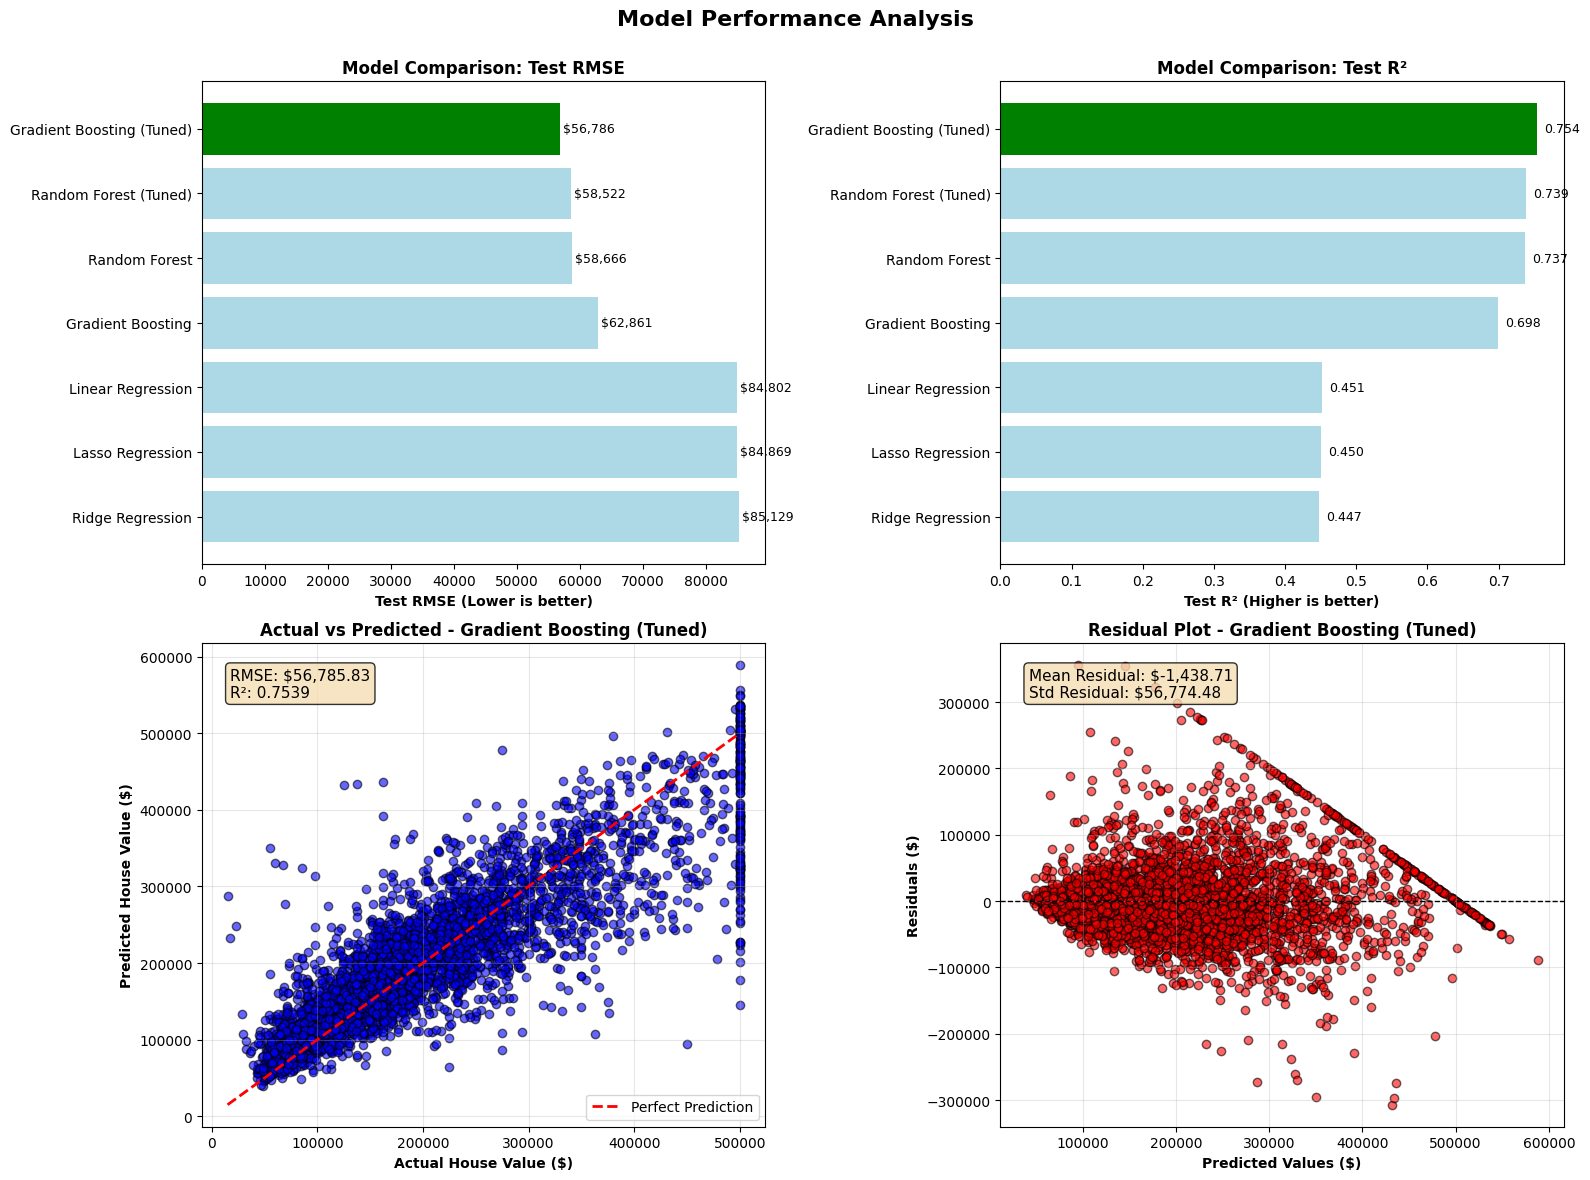


FEATURE IMPORTANCE ANALYSIS

📈 Top 5 important features for Random Forest:
   1. IncomePerRoom: 35.06%
   2. MedInc: 9.72%
   3. MedInc_Cubed: 8.98%
   4. LatLongInteraction: 8.44%
   5. MedInc_Squared: 8.42%


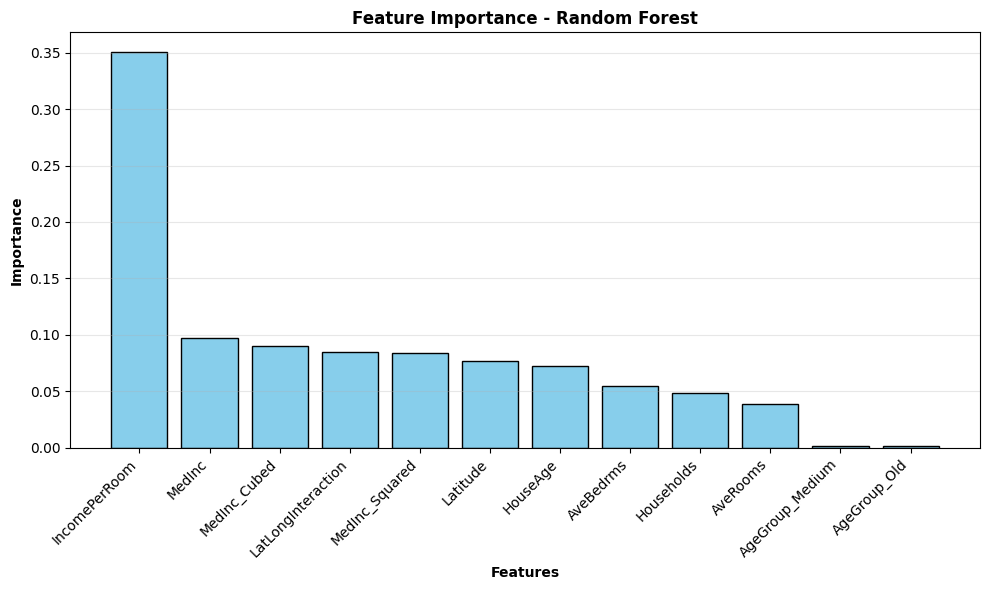


📈 Top 5 important features for Random Forest (Tuned):
   1. IncomePerRoom: 35.84%
   2. MedInc: 10.27%
   3. MedInc_Squared: 9.23%
   4. LatLongInteraction: 8.37%
   5. MedInc_Cubed: 7.90%


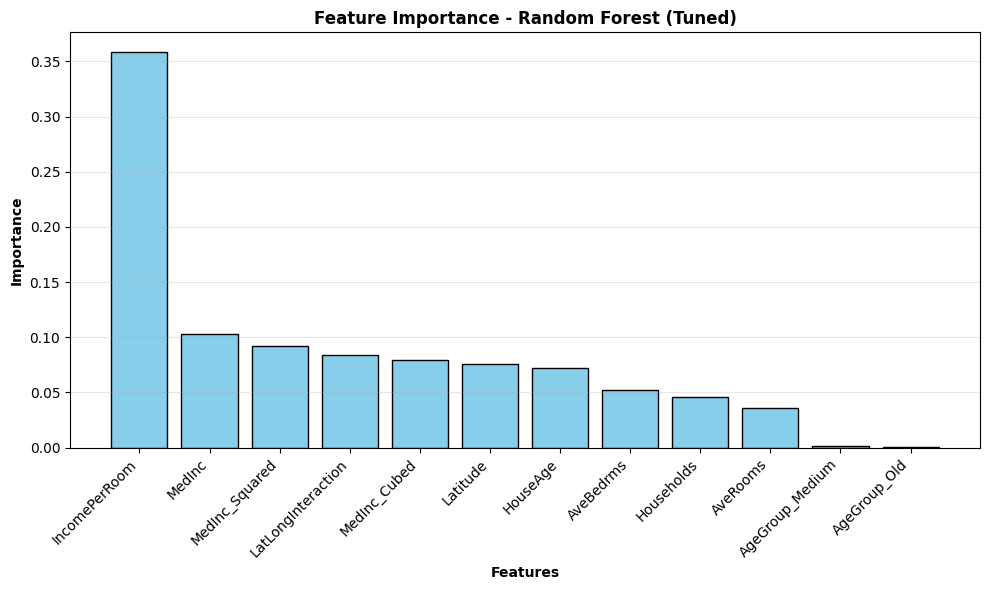


📈 Top 5 important features for Gradient Boosting:
   1. IncomePerRoom: 37.85%
   2. MedInc_Cubed: 16.24%
   3. MedInc: 11.11%
   4. MedInc_Squared: 9.35%
   5. Latitude: 7.17%


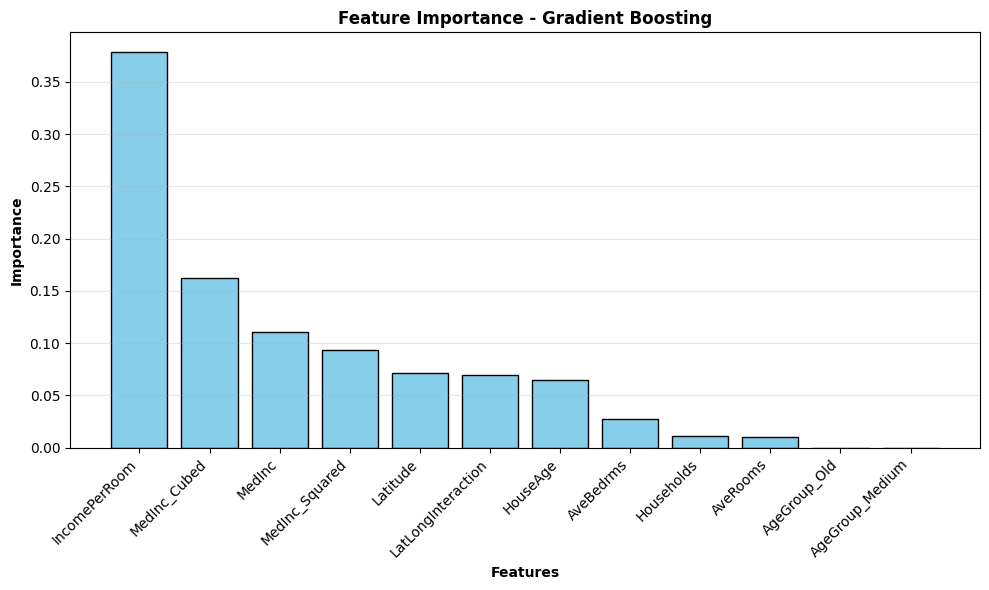


📈 Top 5 important features for Gradient Boosting (Tuned):
   1. IncomePerRoom: 34.97%
   2. MedInc: 13.71%
   3. MedInc_Cubed: 12.18%
   4. LatLongInteraction: 9.45%
   5. Latitude: 9.15%


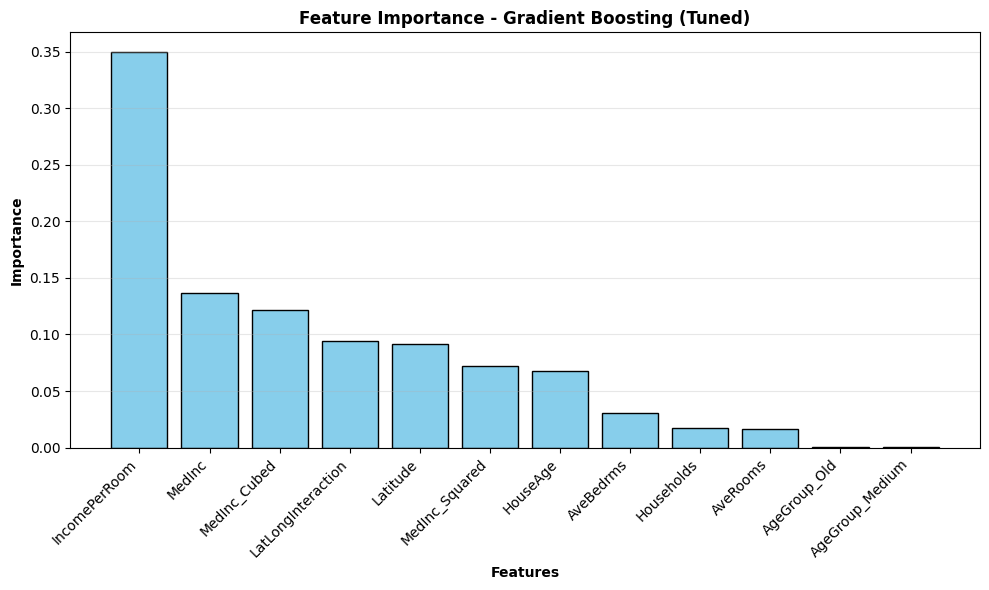


ANALYSIS COMPLETE!


In [14]:
# Cell 7: Model Comparison and Visualization
print("="*60)
print("MODEL COMPARISON AND VISUALIZATION")
print("="*60)

# 1. Create comparison DataFrame with ALL models (including tuned)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test RMSE': [results[m]['test_rmse'] for m in results.keys()],
    'Test R²': [results[m]['test_r2'] for m in results.keys()],
    'Train RMSE': [results[m]['train_rmse'] for m in results.keys()],
    'Train R²': [results[m]['train_r2'] for m in results.keys()]
})

# Sort by Test RMSE (lower is better)
comparison_df = comparison_df.sort_values('Test RMSE')

print("\n📊 MODEL PERFORMANCE COMPARISON (ALL MODELS):")
print("-" * 70)
print(comparison_df.to_string(index=False))

print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_test_rmse = comparison_df.iloc[0]['Test RMSE']
best_test_r2 = comparison_df.iloc[0]['Test R²']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test RMSE: ${best_test_rmse:,.2f}")
print(f"   Test R²: {best_test_r2:.4f}")
print(f"   Improvement over baseline (Linear Regression): {((84801.67 - best_test_rmse) / 84801.67 * 100):.1f}%")

# 2. Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1: Test RMSE comparison (horizontal bar)
bars1 = axes[0, 0].barh(range(len(comparison_df)), comparison_df['Test RMSE'], 
                        color=['green' if i == 0 else 'lightblue' for i in range(len(comparison_df))])
axes[0, 0].set_yticks(range(len(comparison_df)))
axes[0, 0].set_yticklabels(comparison_df['Model'], fontsize=10)
axes[0, 0].set_xlabel('Test RMSE (Lower is better)', fontweight='bold')
axes[0, 0].set_title('Model Comparison: Test RMSE', fontweight='bold')
axes[0, 0].invert_yaxis()  # Highest RMSE at top
# Add value labels
for i, bar in enumerate(bars1):
    width = bar.get_width()
    axes[0, 0].text(width + 500, bar.get_y() + bar.get_height()/2, 
                   f'${width:,.0f}', ha='left', va='center', fontsize=9)

# Plot 2: Test R² comparison (horizontal bar)
bars2 = axes[0, 1].barh(range(len(comparison_df)), comparison_df['Test R²'],
                        color=['green' if i == 0 else 'lightblue' for i in range(len(comparison_df))])
axes[0, 1].set_yticks(range(len(comparison_df)))
axes[0, 1].set_yticklabels(comparison_df['Model'], fontsize=10)
axes[0, 1].set_xlabel('Test R² (Higher is better)', fontweight='bold')
axes[0, 1].set_title('Model Comparison: Test R²', fontweight='bold')
axes[0, 1].invert_yaxis()
# Add value labels
for i, bar in enumerate(bars2):
    width = bar.get_width()
    axes[0, 1].text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{width:.3f}', ha='left', va='center', fontsize=9)

# Plot 3: Actual vs Predicted for best model
best_pred = results[best_model_name]['y_test_pred']
scatter = axes[1, 0].scatter(y_test, best_pred, alpha=0.6, c='blue', edgecolors='black')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual House Value ($)', fontweight='bold')
axes[1, 0].set_ylabel('Predicted House Value ($)', fontweight='bold')
axes[1, 0].set_title(f'Actual vs Predicted - {best_model_name}', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Add metrics to plot
rmse_text = f'RMSE: ${results[best_model_name]["test_rmse"]:,.2f}'
r2_text = f'R²: {results[best_model_name]["test_r2"]:.4f}'
axes[1, 0].text(0.05, 0.95, f'{rmse_text}\n{r2_text}', 
                transform=axes[1, 0].transAxes, 
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 4: Residual plot for best model
residuals = y_test - best_pred
axes[1, 1].scatter(best_pred, residuals, alpha=0.6, c='red', edgecolors='black')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Predicted Values ($)', fontweight='bold')
axes[1, 1].set_ylabel('Residuals ($)', fontweight='bold')
axes[1, 1].set_title(f'Residual Plot - {best_model_name}', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Add statistics about residuals
mean_residual = residuals.mean()
std_residual = residuals.std()
axes[1, 1].text(0.05, 0.95, f'Mean Residual: ${mean_residual:,.2f}\nStd Residual: ${std_residual:,.2f}', 
                transform=axes[1, 1].transAxes, 
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# 3. Feature importance for tree-based models
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Check which models have feature_importance_ attribute
tree_models = ['Random Forest', 'Random Forest (Tuned)', 
               'Gradient Boosting', 'Gradient Boosting (Tuned)']

for model_name in tree_models:
    if model_name in results:
        model = results[model_name]['model']
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1]
            
            print(f"\n📈 Top 5 important features for {model_name}:")
            for i in range(min(5, len(selected_features))):
                importance_percent = importances[indices[i]] * 100
                print(f"   {i+1}. {selected_features[indices[i]]}: {importance_percent:.2f}%")
            
            # Plot feature importance
            plt.figure(figsize=(10, 6))
            plt.bar(range(len(selected_features)), importances[indices], color='skyblue', edgecolor='black')
            plt.xticks(range(len(selected_features)), 
                      [selected_features[i] for i in indices], rotation=45, ha='right', fontsize=10)
            plt.xlabel('Features', fontweight='bold')
            plt.ylabel('Importance', fontweight='bold')
            plt.title(f'Feature Importance - {model_name}', fontweight='bold')
            plt.grid(True, alpha=0.3, axis='y')
            plt.tight_layout()
            plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

ERROR ANALYSIS AND BUSINESS INSIGHTS

📊 ERROR STATISTICS:
----------------------------------------
Mean Absolute Error: $39,210.81
Median Absolute Error: $27,649.09
Mean Absolute Percentage Error: 23.18%
Maximum Error: $355,391.59
Minimum Error: $9.77
Error Standard Deviation: $56,774.48

🔍 ERROR DISTRIBUTION ANALYSIS:
----------------------------------------
Low Error (≤10%): 1457 houses (35.3%)
Medium Error (10-20%): 1013 houses (24.5%)
High Error (>20%): 1658 houses (40.2%)


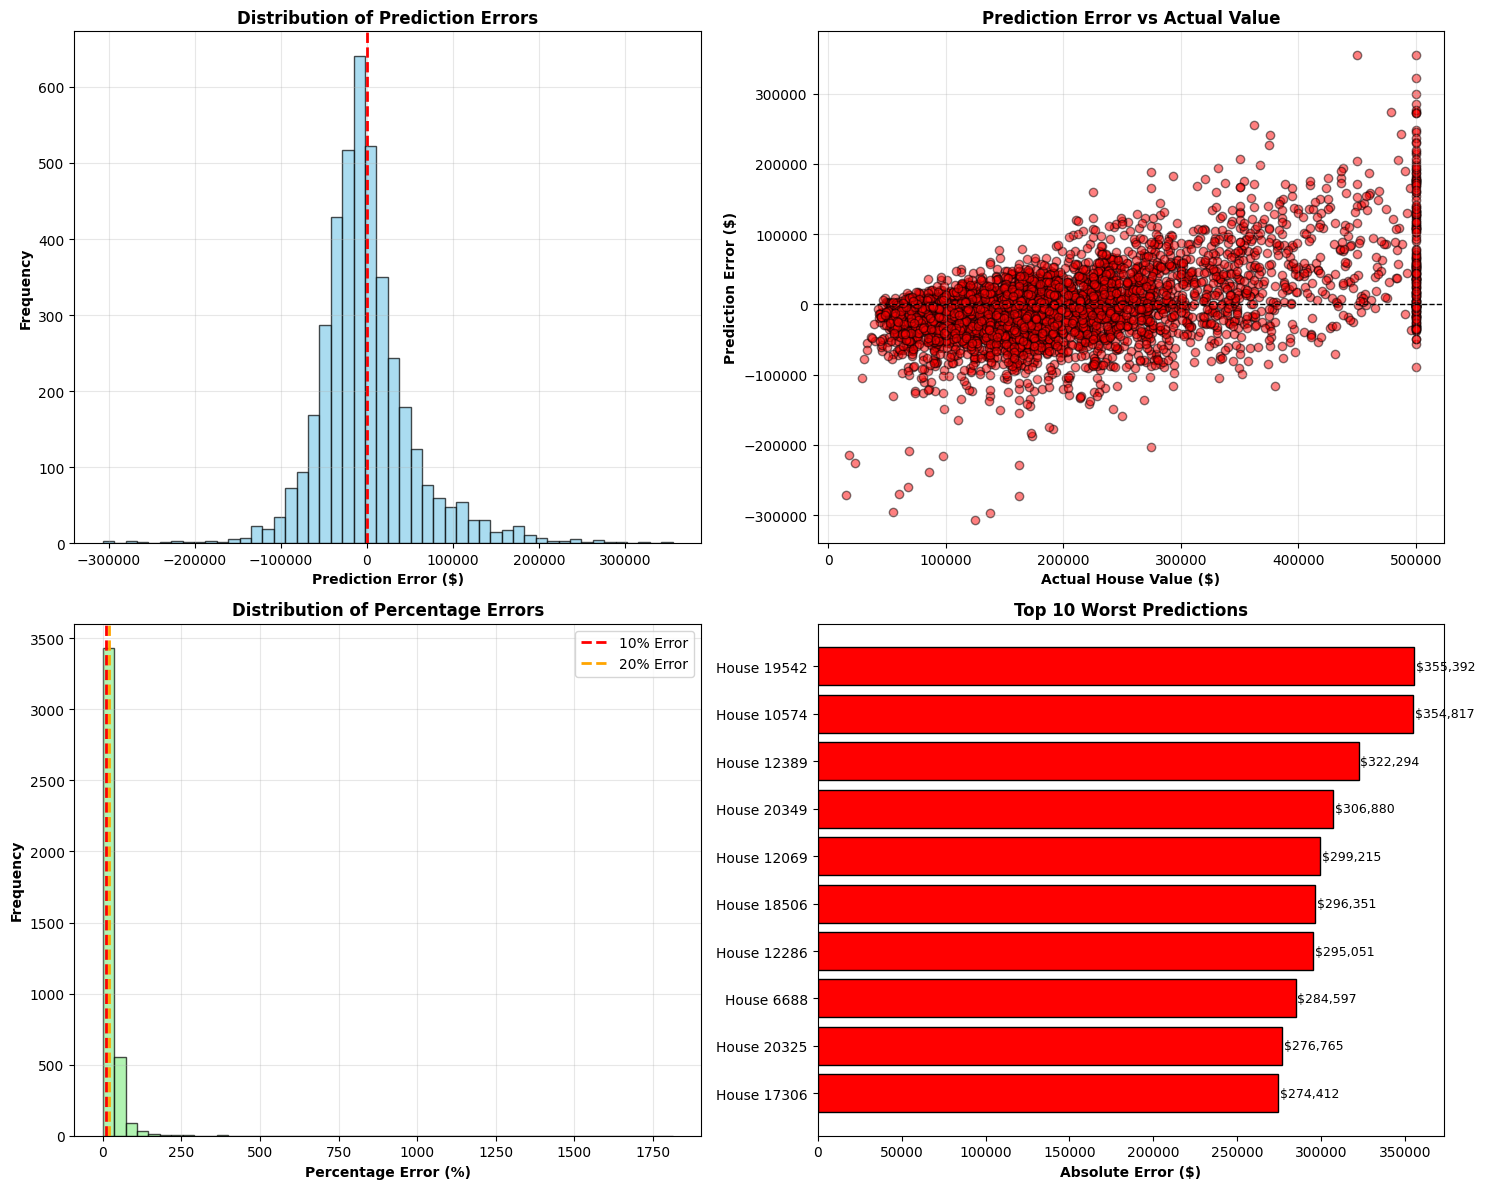


BUSINESS INSIGHTS & RECOMMENDATIONS

📈 MODEL PERFORMANCE:
• The model can predict house prices within $39,211 on average
• 35.3% of predictions are within 10% of actual price
• 40.2% of predictions have >20% error (needs investigation)

💰 FINANCIAL IMPLICATIONS:
• Mean prediction error: $-1,438.71
• Standard deviation of errors: $56,774.48
• For a $500,000 house, typical error is ~$115,902

🔧 RECOMMENDATIONS FOR IMPROVEMENT:
1. Collect more data on high-error houses
2. Add neighborhood-specific features
3. Consider time-series factors if available
4. Use ensemble methods combining multiple models
5. Regular model retraining with new data


In [16]:
# Cell 8: Error Analysis and Business Insights
print("="*60)
print("ERROR ANALYSIS AND BUSINESS INSIGHTS")
print("="*60)

# Get predictions from best model
best_model = results[best_model_name]['model']
y_pred = best_model.predict(X_test_scaled)

# 1. Calculate prediction errors
prediction_errors = y_test - y_pred
absolute_errors = np.abs(prediction_errors)
percentage_errors = (absolute_errors / y_test) * 100

# Create error analysis DataFrame
error_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': prediction_errors,
    'Absolute_Error': absolute_errors,
    'Percentage_Error': percentage_errors
})

# 2. Add original features for analysis
for feature in selected_features[:5]:  # Top 5 features
    error_df[feature] = X_test_scaled[feature].values

print("\n📊 ERROR STATISTICS:")
print("-" * 40)
print(f"Mean Absolute Error: ${absolute_errors.mean():,.2f}")
print(f"Median Absolute Error: ${np.median(absolute_errors):,.2f}")
print(f"Mean Absolute Percentage Error: {percentage_errors.mean():.2f}%")
print(f"Maximum Error: ${absolute_errors.max():,.2f}")
print(f"Minimum Error: ${absolute_errors.min():,.2f}")
print(f"Error Standard Deviation: ${prediction_errors.std():,.2f}")

# 3. Analyze where model performs well/poorly
print("\n🔍 ERROR DISTRIBUTION ANALYSIS:")
print("-" * 40)

# Define error thresholds
low_error = error_df[error_df['Percentage_Error'] <= 10]
medium_error = error_df[(error_df['Percentage_Error'] > 10) & (error_df['Percentage_Error'] <= 20)]
high_error = error_df[error_df['Percentage_Error'] > 20]

print(f"Low Error (≤10%): {len(low_error)} houses ({len(low_error)/len(error_df)*100:.1f}%)")
print(f"Medium Error (10-20%): {len(medium_error)} houses ({len(medium_error)/len(error_df)*100:.1f}%)")
print(f"High Error (>20%): {len(high_error)} houses ({len(high_error)/len(error_df)*100:.1f}%)")

# 4. Visualize error analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Error distribution histogram
axes[0, 0].hist(prediction_errors, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Prediction Error ($)', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Distribution of Prediction Errors', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Error vs Actual Value
axes[0, 1].scatter(y_test, prediction_errors, alpha=0.5, c='red', edgecolors='black')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Actual House Value ($)', fontweight='bold')
axes[0, 1].set_ylabel('Prediction Error ($)', fontweight='bold')
axes[0, 1].set_title('Prediction Error vs Actual Value', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Percentage Error distribution
axes[1, 0].hist(percentage_errors, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].axvline(x=10, color='red', linestyle='--', linewidth=2, label='10% Error')
axes[1, 0].axvline(x=20, color='orange', linestyle='--', linewidth=2, label='20% Error')
axes[1, 0].set_xlabel('Percentage Error (%)', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Percentage Errors', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Top 10 worst predictions
worst_predictions = error_df.nlargest(10, 'Absolute_Error')
bars = axes[1, 1].barh(range(len(worst_predictions)), worst_predictions['Absolute_Error'], 
                       color='red', edgecolor='black')
axes[1, 1].set_yticks(range(len(worst_predictions)))
axes[1, 1].set_yticklabels([f'House {idx}' for idx in worst_predictions.index[:10]])
axes[1, 1].set_xlabel('Absolute Error ($)', fontweight='bold')
axes[1, 1].set_title('Top 10 Worst Predictions', fontweight='bold')
axes[1, 1].invert_yaxis()
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    axes[1, 1].text(width + 1000, bar.get_y() + bar.get_height()/2, 
                   f'${width:,.0f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 5. Business Insights
print("\n" + "="*60)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)

print("\n📈 MODEL PERFORMANCE:")
print(f"• The model can predict house prices within ${absolute_errors.mean():,.0f} on average")
print(f"• {len(low_error)/len(error_df)*100:.1f}% of predictions are within 10% of actual price")
print(f"• {len(high_error)/len(error_df)*100:.1f}% of predictions have >20% error (needs investigation)")

print("\n💰 FINANCIAL IMPLICATIONS:")
print(f"• Mean prediction error: ${prediction_errors.mean():,.2f}")
print(f"• Standard deviation of errors: ${prediction_errors.std():,.2f}")
print("• For a $500,000 house, typical error is ~${:,.0f}".format(500000 * (percentage_errors.mean()/100)))

print("\n🔧 RECOMMENDATIONS FOR IMPROVEMENT:")
print("1. Collect more data on high-error houses")
print("2. Add neighborhood-specific features")
print("3. Consider time-series factors if available")
print("4. Use ensemble methods combining multiple models")
print("5. Regular model retraining with new data")

In [17]:
# Cell 9: Save Best Model and Create Prediction Pipeline
print("="*60)
print("MODEL SAVING AND DEPLOYMENT PREPARATION")
print("="*60)

import joblib
import json
from datetime import datetime

# 1. Prepare all components for saving
model_pipeline = {
    'model': best_model,
    'scaler': scaler,
    'feature_selector': selector,
    'selected_features': list(selected_features),
    'all_features': list(X.columns),
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'performance_metrics': {
        'test_rmse': results[best_model_name]['test_rmse'],
        'test_r2': results[best_model_name]['test_r2'],
        'train_rmse': results[best_model_name]['train_rmse'],
        'train_r2': results[best_model_name]['train_r2']
    },
    'model_parameters': best_model.get_params() if hasattr(best_model, 'get_params') else {}
}

# 2. Create directories if they don't exist
import os
os.makedirs('saved_models', exist_ok=True)
os.makedirs('model_artifacts', exist_ok=True)

# 3. Save the complete pipeline
model_filename = f'saved_models/best_model_{best_model_name.replace(" ", "_").lower()}.joblib'
joblib.dump(model_pipeline, model_filename)

# 4. Save performance metrics separately
metrics_data = {
    'model_name': best_model_name,
    'performance': model_pipeline['performance_metrics'],
    'features_used': model_pipeline['selected_features'],
    'training_info': {
        'date': model_pipeline['training_date'],
        'dataset_size': f'{X.shape[0]} samples, {X.shape[1]} features',
        'train_test_split': '80/20'
    }
}

with open('model_artifacts/model_metrics.json', 'w') as f:
    json.dump(metrics_data, f, indent=4)

# 5. Create a sample prediction function
def predict_house_price(input_features):
    """
    Predict house price using saved model pipeline
    input_features: dict with feature names as keys
    """
    try:
        # Load the model pipeline
        pipeline = joblib.load(model_filename)
        
        # Create DataFrame from input
        input_df = pd.DataFrame([input_features])
        
        # Ensure all features are present
        for feature in pipeline['all_features']:
            if feature not in input_df.columns:
                input_df[feature] = 0  # Fill missing with 0
        
        # Reorder columns to match training
        input_df = input_df[pipeline['all_features']]
        
        # Apply scaling
        input_scaled = pipeline['scaler'].transform(input_df)
        
        # Apply feature selection
        input_selected = pipeline['feature_selector'].transform(input_scaled)
        
        # Make prediction
        prediction = pipeline['model'].predict(input_selected)[0]
        
        # Calculate confidence interval (simplified)
        std_error = pipeline['performance_metrics']['test_rmse']
        lower_bound = prediction - 1.96 * std_error
        upper_bound = prediction + 1.96 * std_error
        
        return {
            'predicted_price': float(prediction),
            'confidence_interval': {
                'lower_bound': float(lower_bound),
                'upper_bound': float(upper_bound)
            },
            'model_used': pipeline['performance_metrics'],
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        
    except Exception as e:
        return {'error': str(e)}

# 6. Test the prediction function with sample data
print("\n🧪 TESTING PREDICTION FUNCTION...")

# Get a sample house from test set
sample_idx = X_test.index[0]
sample_house = X.loc[sample_idx].to_dict()
actual_price = y.loc[sample_idx]

print(f"\nSample House Features:")
for key, value in list(sample_house.items())[:5]:  # Show first 5 features
    print(f"  {key}: {value:.4f}")
print(f"  ... and {len(sample_house)-5} more features")

# Make prediction
prediction_result = predict_house_price(sample_house)

print(f"\n📊 PREDICTION RESULTS:")
print(f"  Actual Price: ${actual_price:,.2f}")
print(f"  Predicted Price: ${prediction_result['predicted_price']:,.2f}")
print(f"  95% Confidence Interval: ${prediction_result['confidence_interval']['lower_bound']:,.2f} - ${prediction_result['confidence_interval']['upper_bound']:,.2f}")
print(f"  Error: ${abs(actual_price - prediction_result['predicted_price']):,.2f}")
print(f"  Percentage Error: {abs(actual_price - prediction_result['predicted_price']) / actual_price * 100:.2f}%")

# 7. Save summary report
print("\n" + "="*60)
print("MODEL SAVING SUMMARY")
print("="*60)

print(f"\n✅ Model saved successfully: {model_filename}")
print(f"✅ Metrics saved: model_artifacts/model_metrics.json")
print(f"✅ Model type: {best_model_name}")
print(f"✅ Test RMSE: ${results[best_model_name]['test_rmse']:,.2f}")
print(f"✅ Test R²: {results[best_model_name]['test_r2']:.4f}")
print(f"✅ Features used: {len(selected_features)} out of {len(X.columns)}")
print(f"✅ Training date: {model_pipeline['training_date']}")

# 8. Create deployment README
readme_content = f"""
# California Housing Price Prediction Model

## Model Information
- **Model Name**: {best_model_name}
- **Training Date**: {model_pipeline['training_date']}
- **Dataset**: California Housing Prices ({X.shape[0]} samples, {X.shape[1]} features)

## Performance Metrics
- **Test RMSE**: ${results[best_model_name]['test_rmse']:,.2f}
- **Test R²**: {results[best_model_name]['test_r2']:.4f}
- **Train RMSE**: ${results[best_model_name]['train_rmse']:,.2f}
- **Train R²**: {results[best_model_name]['train_r2']:.4f}

## Selected Features ({len(selected_features)} features)
{', '.join(selected_features)}

## How to Use
1. Load the model: `pipeline = joblib.load('{model_filename}')`
2. Prepare input data as dictionary with all original features
3. Use the `predict_house_price()` function for predictions

## Files Created
- `{model_filename}`: Complete model pipeline (model + preprocessing)
- `model_artifacts/model_metrics.json`: Performance metrics
- This README file

## Requirements
- Python 3.7+
- scikit-learn, pandas, numpy, joblib
"""

with open('model_artifacts/README.md', 'w') as f:
    f.write(readme_content)

print(f"\n✅ README created: model_artifacts/README.md")
print("\n🎉 MODEL DEVELOPMENT PIPELINE COMPLETED SUCCESSFULLY!")
print("="*60)

MODEL SAVING AND DEPLOYMENT PREPARATION

🧪 TESTING PREDICTION FUNCTION...

Sample House Features:
  MedInc: 1.6812
  HouseAge: 25.0000
  AveRooms: 4.1922
  AveBedrms: 1.2117
  Population: 1392.0000
  ... and 11 more features

📊 PREDICTION RESULTS:
  Actual Price: $47,700.00
  Predicted Price: $76,950.87
  95% Confidence Interval: $-34,349.35 - $188,251.10
  Error: $29,250.87
  Percentage Error: 61.32%

MODEL SAVING SUMMARY

✅ Model saved successfully: saved_models/best_model_gradient_boosting_(tuned).joblib
✅ Metrics saved: model_artifacts/model_metrics.json
✅ Model type: Gradient Boosting (Tuned)
✅ Test RMSE: $56,785.83
✅ Test R²: 0.7539
✅ Features used: 12 out of 16
✅ Training date: 2025-12-28 17:02:14

✅ README created: model_artifacts/README.md

🎉 MODEL DEVELOPMENT PIPELINE COMPLETED SUCCESSFULLY!
